----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k 10.753 +/- 2.918 11.288 +/- 3.035
 0.5k 11.123 +/- 2.930 11.568 +/- 3.212
0.25k 11.738 +/- 2.857 11.582 +/- 3.206
 0.1k 12.619 +/- 2.856 12.176 +/- 3.747
0.05k 10.486 +/- 2.888 11.108 +/- 3.201




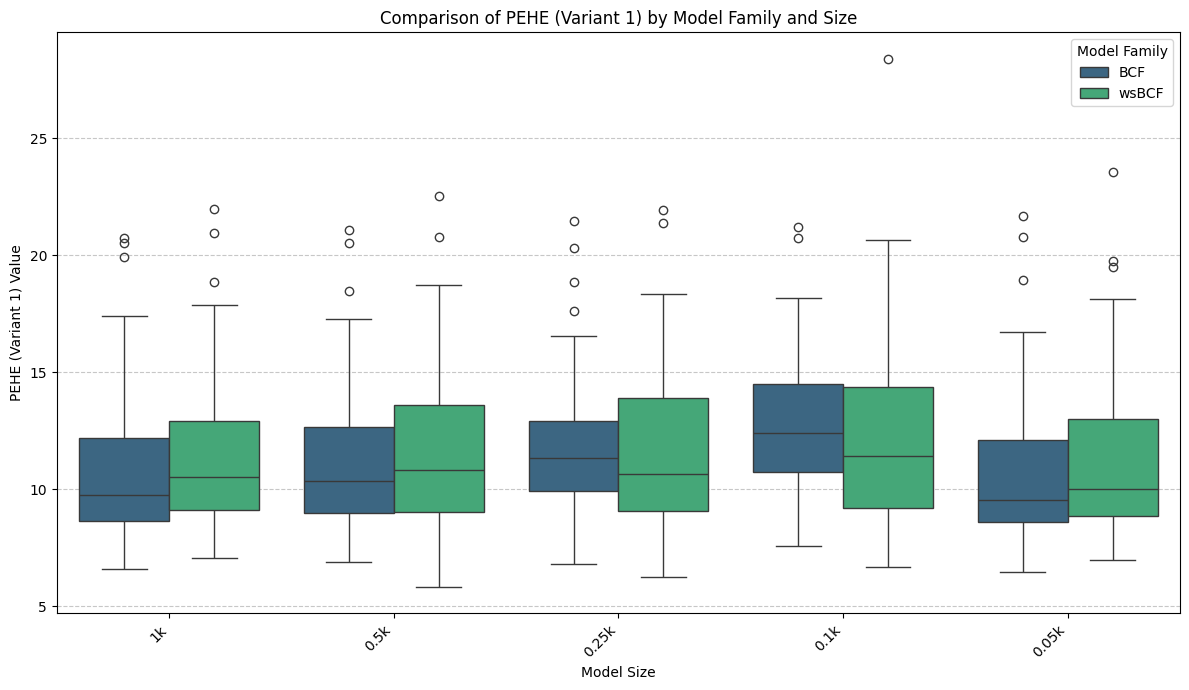

----- Comparison for PEHE (Variant 2) -----
Model              BCF            wsBCF
   1k 10.702 +/- 2.913 10.849 +/- 2.818
 0.5k 10.943 +/- 2.953 10.821 +/- 2.929
0.25k 11.520 +/- 3.057 11.174 +/- 3.015
 0.1k 12.206 +/- 3.079 11.264 +/- 3.142
0.05k 10.474 +/- 2.806 10.698 +/- 2.813




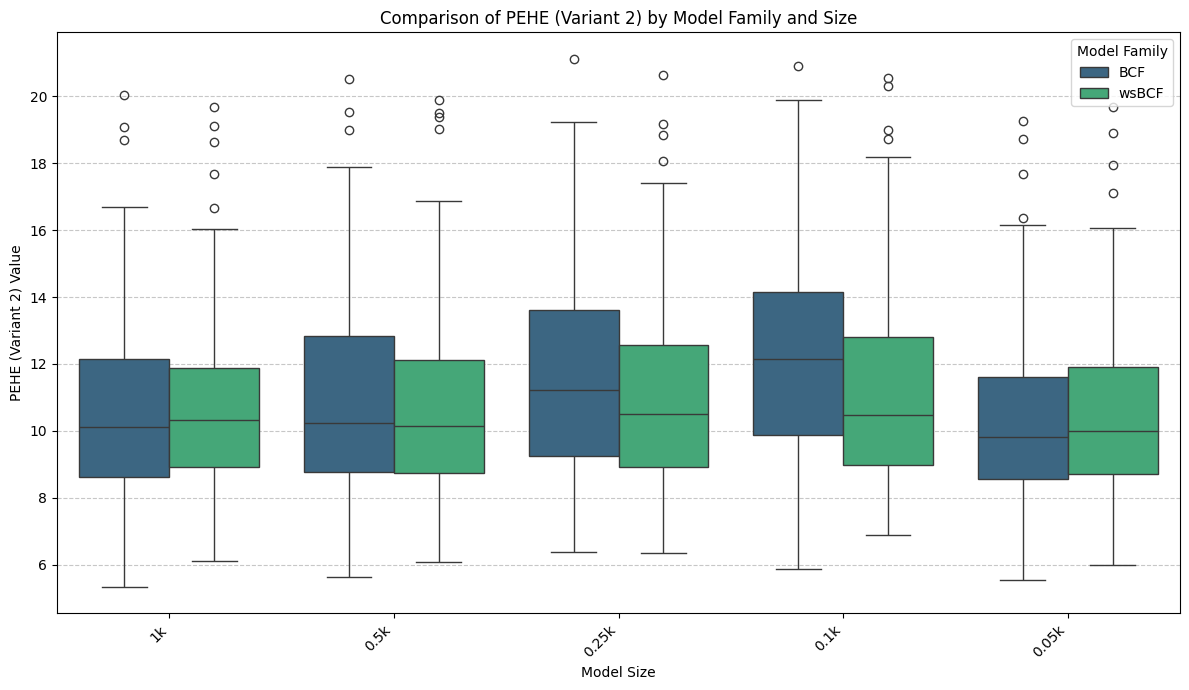

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.970 +/- 0.056 0.965 +/- 0.060
 0.5k 0.966 +/- 0.061 0.965 +/- 0.063
0.25k 0.963 +/- 0.060 0.970 +/- 0.058
 0.1k 0.947 +/- 0.065 0.967 +/- 0.066
0.05k 0.975 +/- 0.047 0.964 +/- 0.065




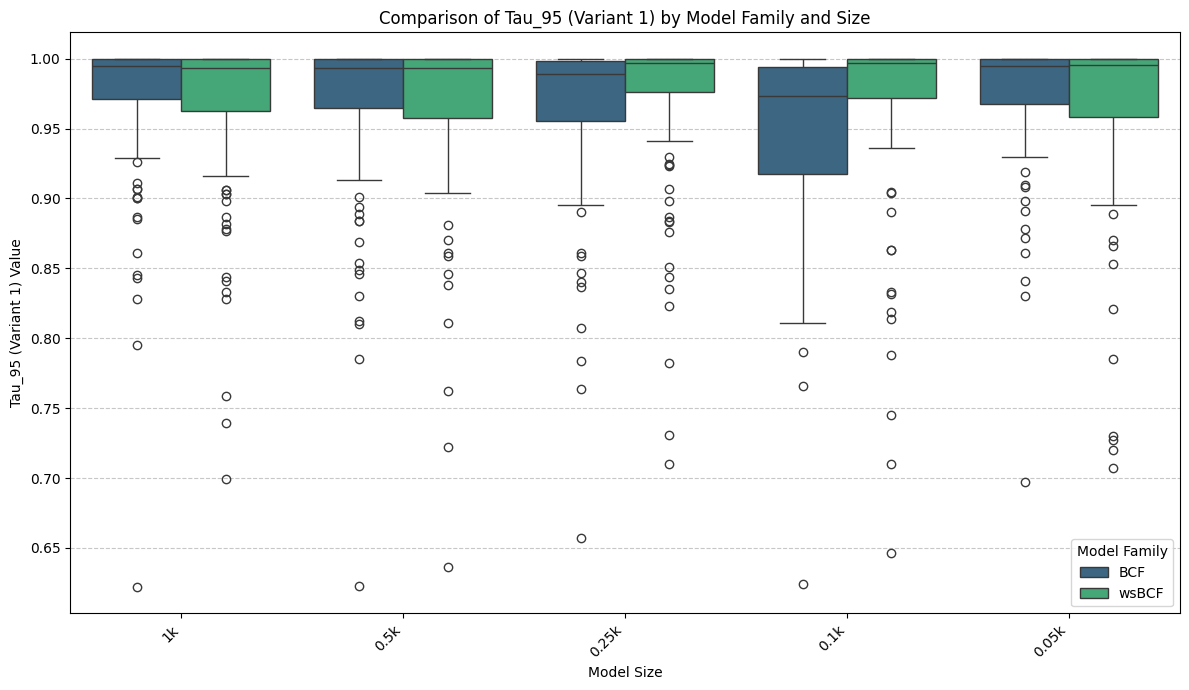

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.966 +/- 0.075 0.964 +/- 0.079
 0.5k 0.962 +/- 0.080 0.965 +/- 0.078
0.25k 0.954 +/- 0.085 0.962 +/- 0.080
 0.1k 0.943 +/- 0.084 0.975 +/- 0.054
0.05k 0.971 +/- 0.065 0.965 +/- 0.075




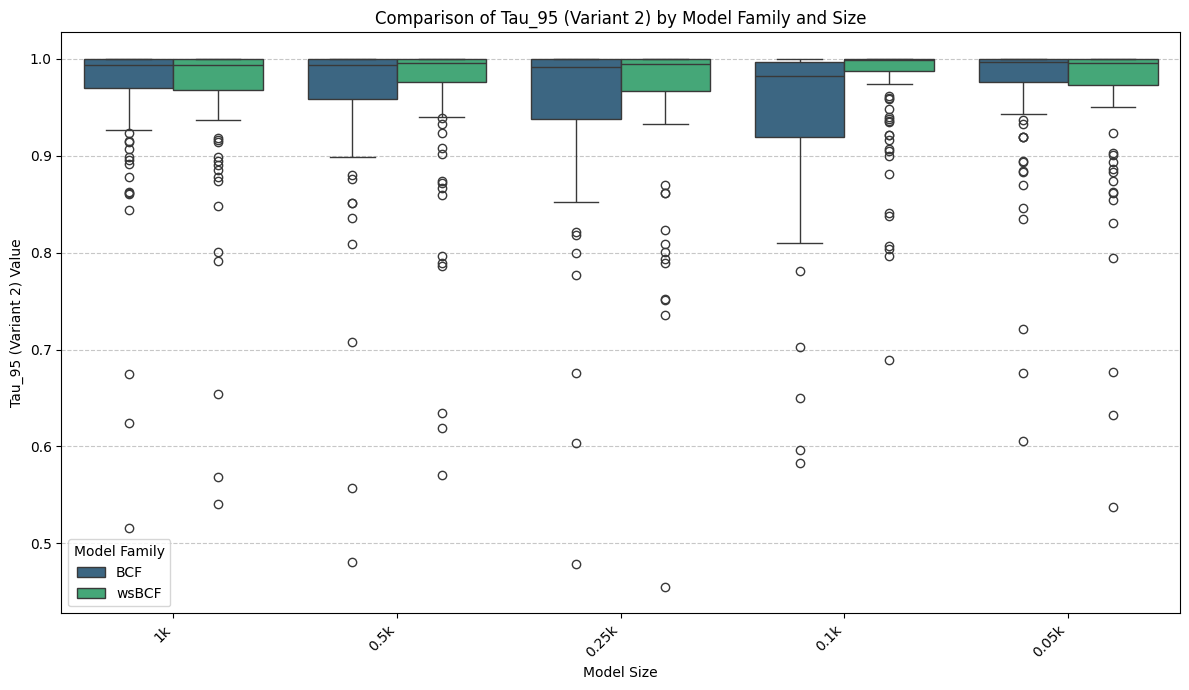

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 49.507 +/- 7.015  49.549 +/- 6.342
 0.5k 50.659 +/- 6.975  51.122 +/- 7.159
0.25k 51.661 +/- 6.409  54.861 +/- 8.855
 0.1k 50.658 +/- 5.929 61.843 +/- 13.771
0.05k 49.141 +/- 6.918  48.758 +/- 6.563




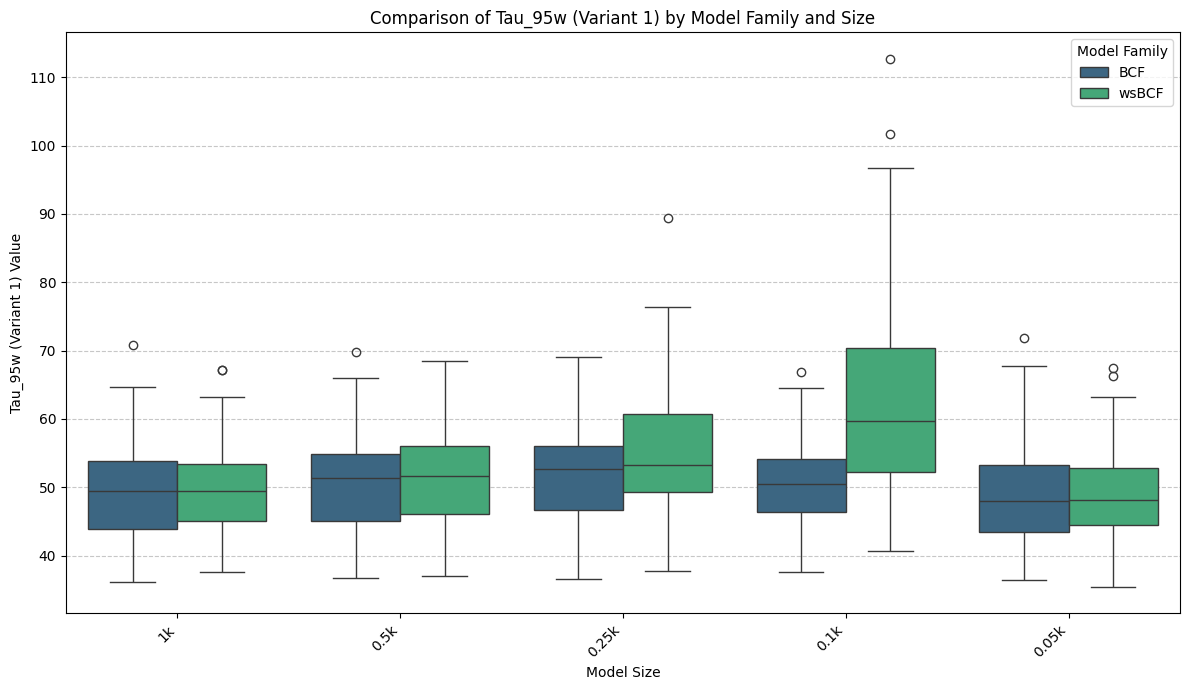

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 49.291 +/- 6.893  49.055 +/- 7.420
 0.5k 49.937 +/- 6.895  49.465 +/- 7.758
0.25k 50.640 +/- 6.611  52.260 +/- 9.313
 0.1k 49.829 +/- 6.075 59.666 +/- 13.352
0.05k 49.090 +/- 6.752  48.517 +/- 6.995




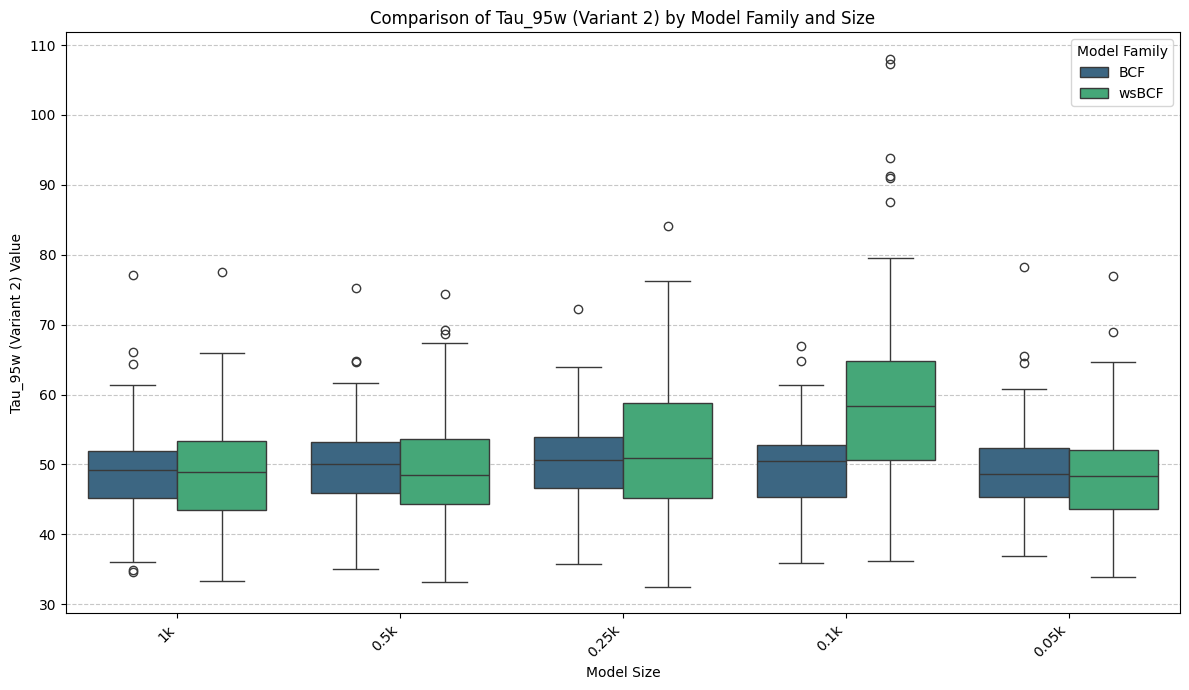

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("multiple_BCF_simulation_results_DGP1.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("multiple_wsBCF_simulation_results_DGP1.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k 37.205 +/- 5.242 37.491 +/- 5.506
 0.5k 36.721 +/- 5.223 37.159 +/- 5.678
0.25k 35.804 +/- 5.146 37.267 +/- 6.136
 0.1k 34.005 +/- 4.865 37.159 +/- 6.344
0.05k 37.451 +/- 5.241 37.623 +/- 5.493




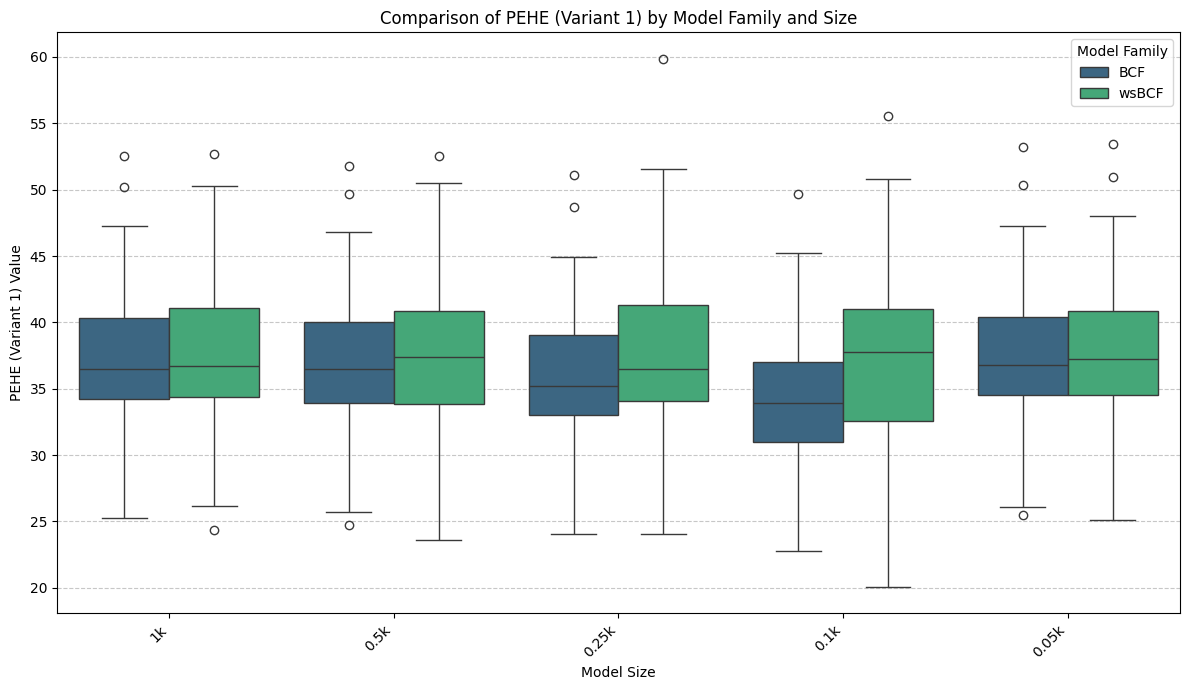

----- Comparison for PEHE (Variant 2) -----
Model             BCF            wsBCF
   1k 9.828 +/- 2.161 10.194 +/- 2.236
 0.5k 9.837 +/- 2.227 10.130 +/- 2.325
0.25k 9.858 +/- 2.237 10.146 +/- 2.467
 0.1k 9.822 +/- 2.301 10.306 +/- 2.683
0.05k 9.901 +/- 2.136 10.169 +/- 2.237




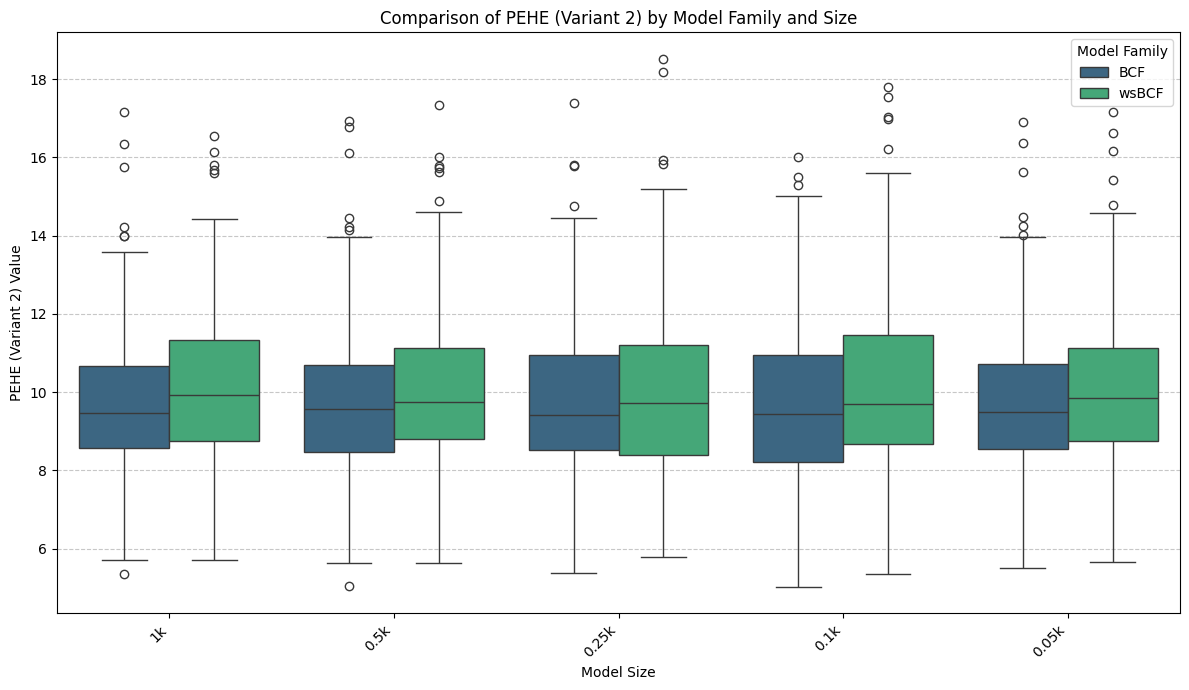

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.252 +/- 0.150 0.252 +/- 0.167
 0.5k 0.281 +/- 0.151 0.311 +/- 0.197
0.25k 0.307 +/- 0.153 0.348 +/- 0.209
 0.1k 0.332 +/- 0.153 0.430 +/- 0.222
0.05k 0.228 +/- 0.147 0.240 +/- 0.164




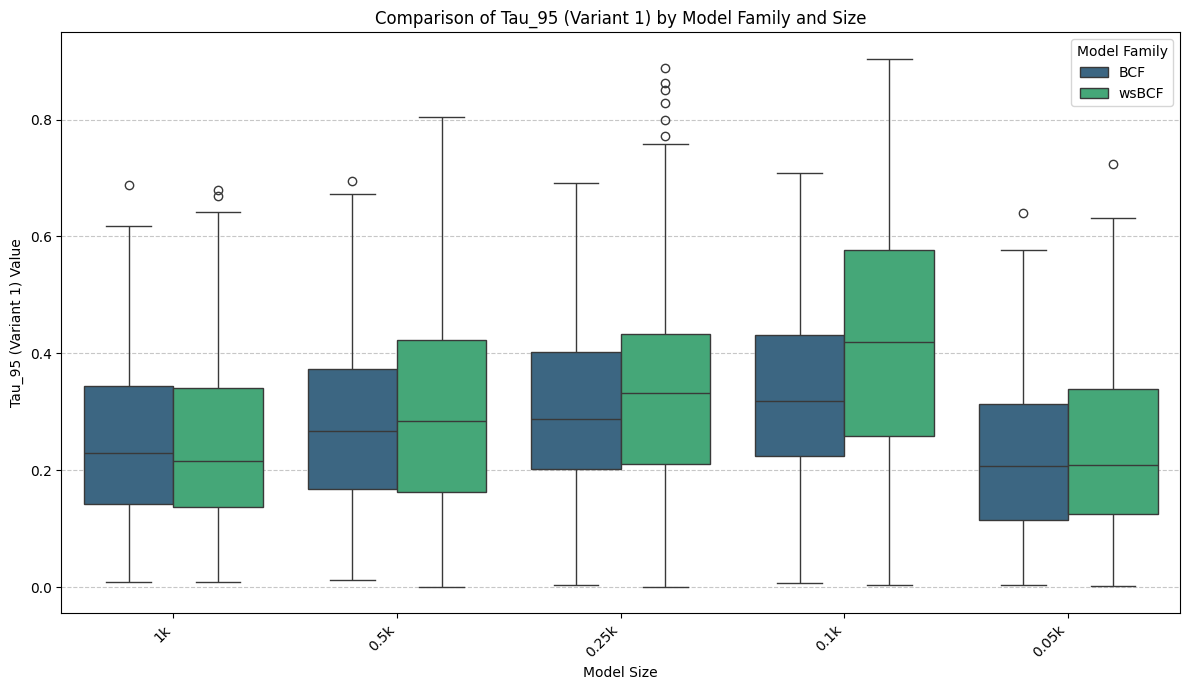

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.969 +/- 0.039 0.964 +/- 0.047
 0.5k 0.973 +/- 0.036 0.969 +/- 0.053
0.25k 0.972 +/- 0.035 0.974 +/- 0.042
 0.1k 0.965 +/- 0.043 0.976 +/- 0.037
0.05k 0.967 +/- 0.040 0.966 +/- 0.050




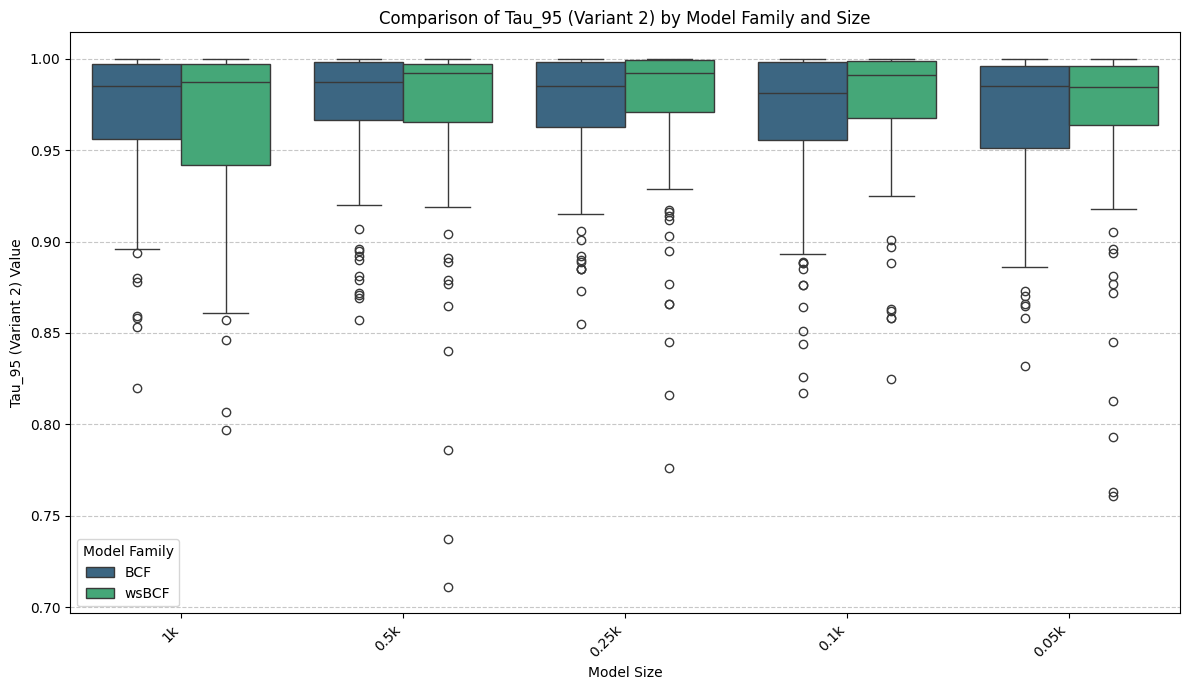

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 56.373 +/- 4.656  57.448 +/- 5.724
 0.5k 57.359 +/- 4.220  60.745 +/- 6.651
0.25k 57.507 +/- 3.790 68.598 +/- 17.282
 0.1k 56.093 +/- 3.690 78.486 +/- 17.660
0.05k 55.033 +/- 5.178  56.310 +/- 5.855




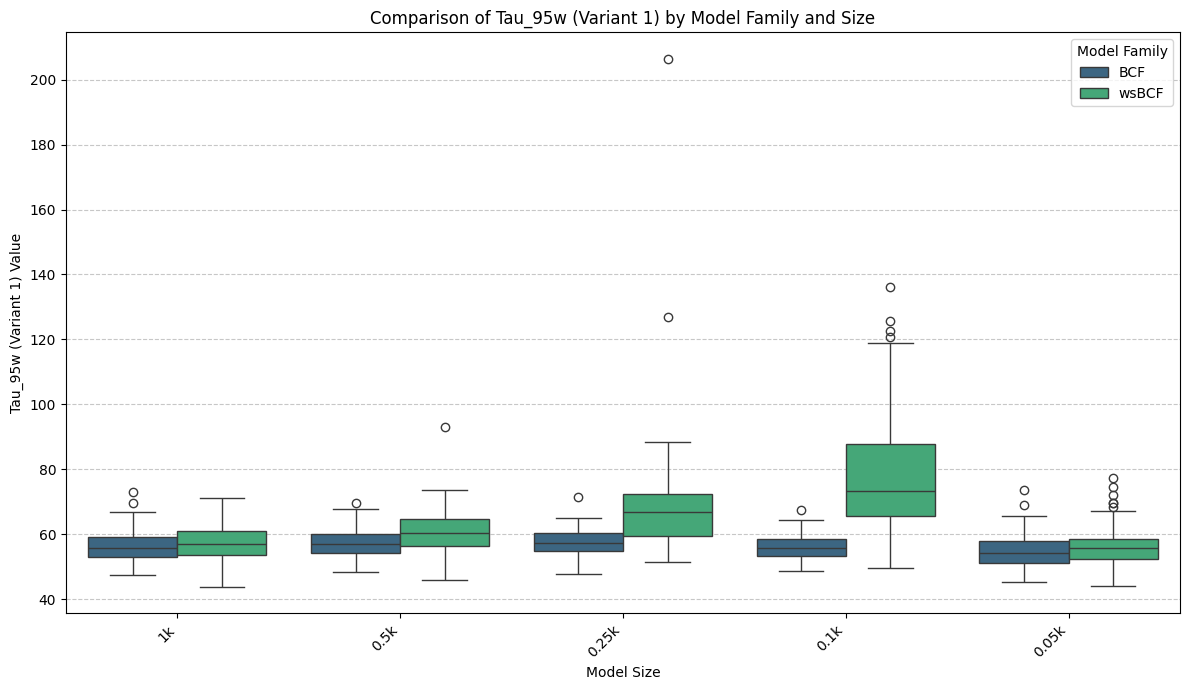

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 44.462 +/- 6.235  45.055 +/- 6.580
 0.5k 45.355 +/- 5.421  47.056 +/- 6.446
0.25k 45.631 +/- 5.121  50.010 +/- 7.641
 0.1k 44.377 +/- 4.814 54.038 +/- 11.148
0.05k 44.139 +/- 6.403  44.950 +/- 6.607




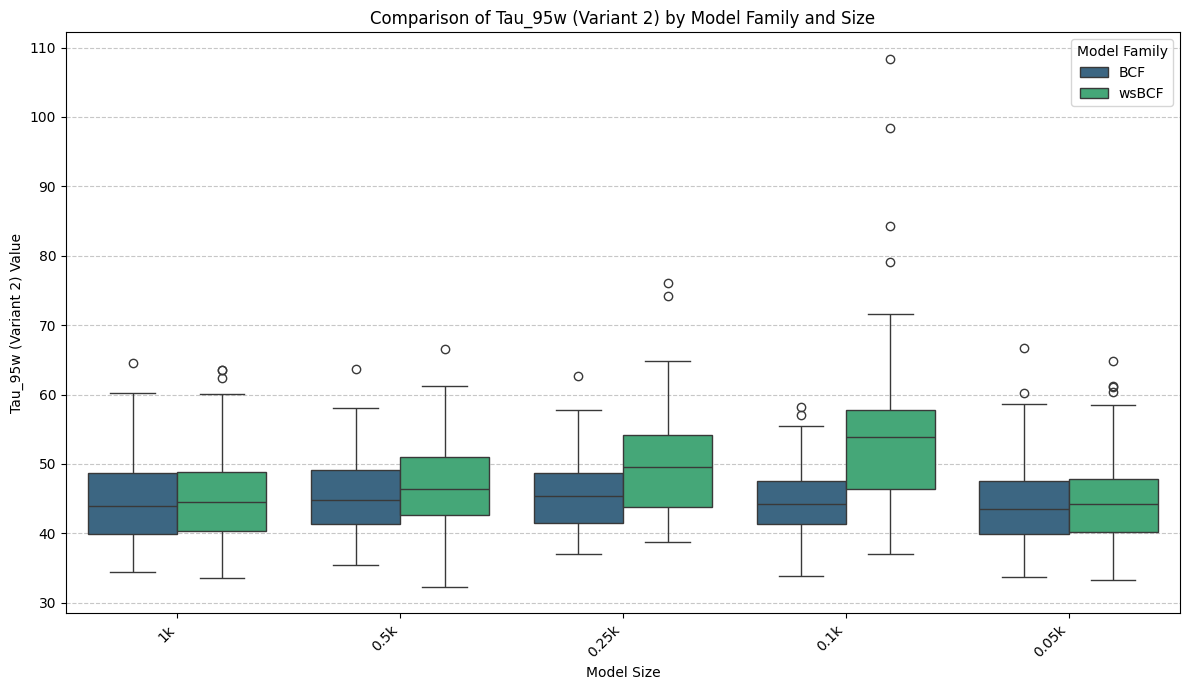

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("multiple_BCF_simulation_results_DGP2.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("multiple_wsBCF_simulation_results_DGP2.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k 11.615 +/- 3.134 11.559 +/- 3.216
 0.5k 12.142 +/- 3.125 11.855 +/- 3.358
0.25k 12.685 +/- 3.027 11.851 +/- 3.502
 0.1k 13.399 +/- 2.910 12.582 +/- 4.110
0.05k 11.369 +/- 3.072 11.270 +/- 3.148




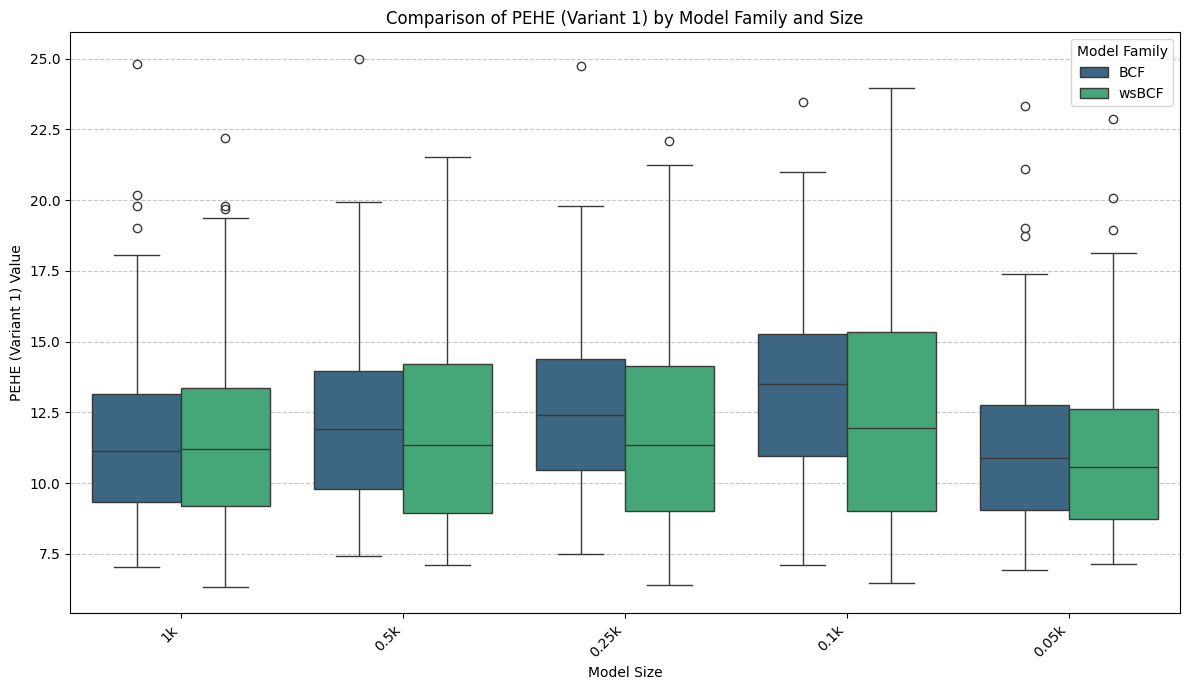

----- Comparison for PEHE (Variant 2) -----
Model              BCF            wsBCF
   1k 10.625 +/- 2.868 10.900 +/- 2.920
 0.5k 10.879 +/- 2.960 10.984 +/- 3.072
0.25k 11.391 +/- 3.085 11.096 +/- 2.832
 0.1k 12.236 +/- 3.122 11.166 +/- 3.208
0.05k 10.444 +/- 2.810 10.550 +/- 2.783




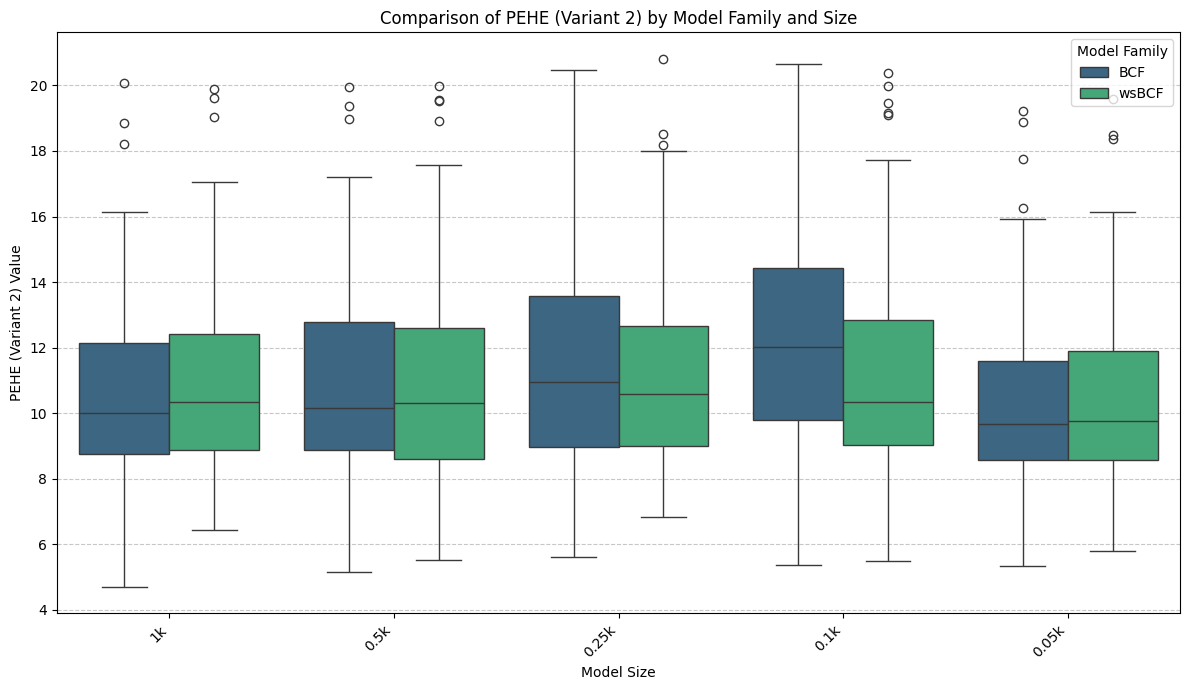

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.964 +/- 0.068 0.960 +/- 0.079
 0.5k 0.961 +/- 0.071 0.954 +/- 0.084
0.25k 0.958 +/- 0.060 0.963 +/- 0.068
 0.1k 0.946 +/- 0.062 0.957 +/- 0.078
0.05k 0.966 +/- 0.065 0.962 +/- 0.070




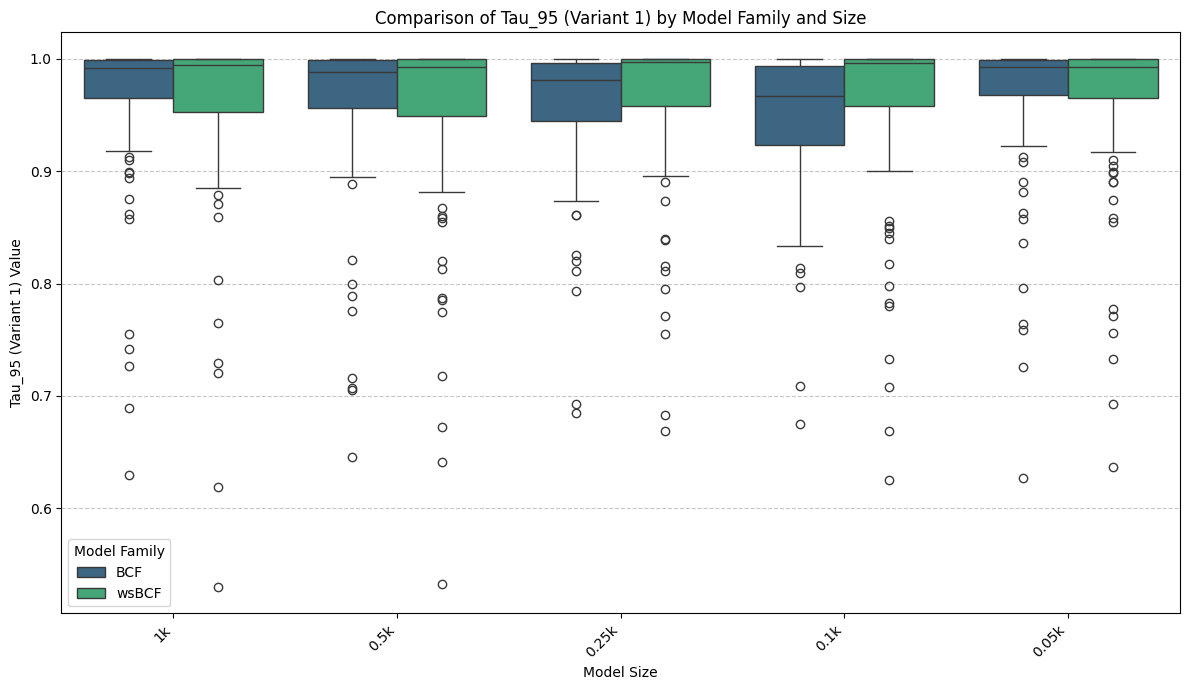

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.967 +/- 0.073 0.960 +/- 0.085
 0.5k 0.963 +/- 0.074 0.958 +/- 0.087
0.25k 0.958 +/- 0.078 0.967 +/- 0.074
 0.1k 0.940 +/- 0.086 0.969 +/- 0.080
0.05k 0.970 +/- 0.067 0.964 +/- 0.075




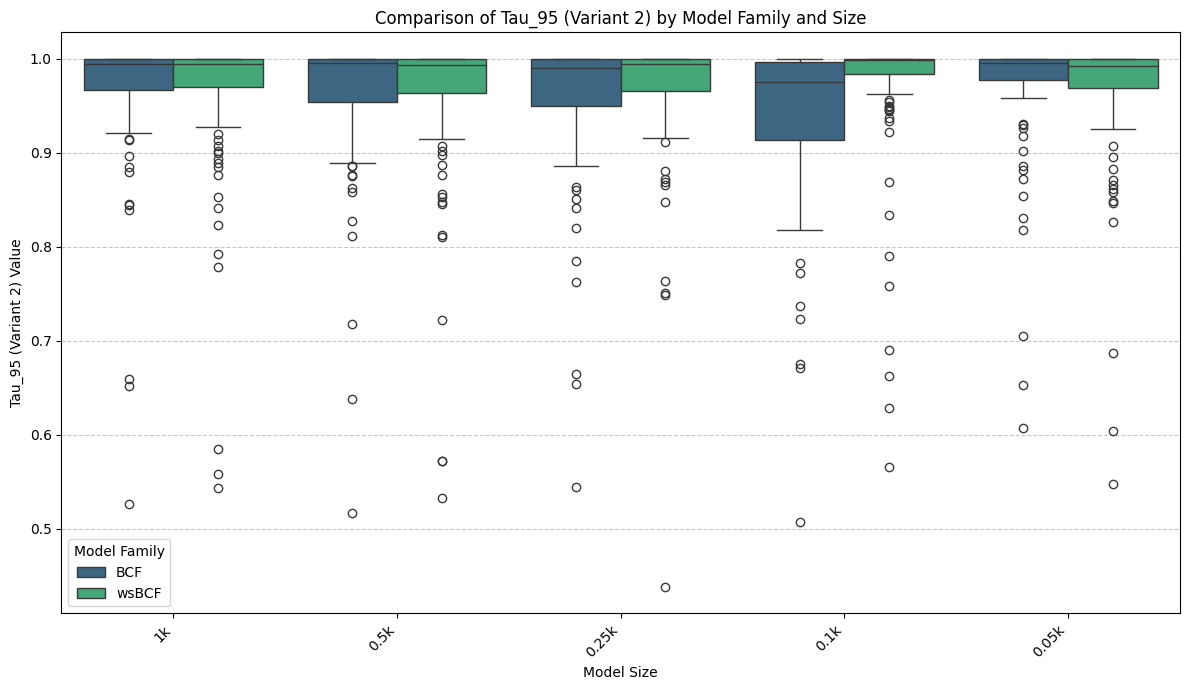

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 53.185 +/- 8.339  51.834 +/- 8.073
 0.5k 54.439 +/- 8.300  52.582 +/- 9.149
0.25k 55.477 +/- 7.110 56.552 +/- 11.360
 0.1k 54.708 +/- 6.380 62.245 +/- 13.824
0.05k 52.296 +/- 8.588  50.795 +/- 8.277




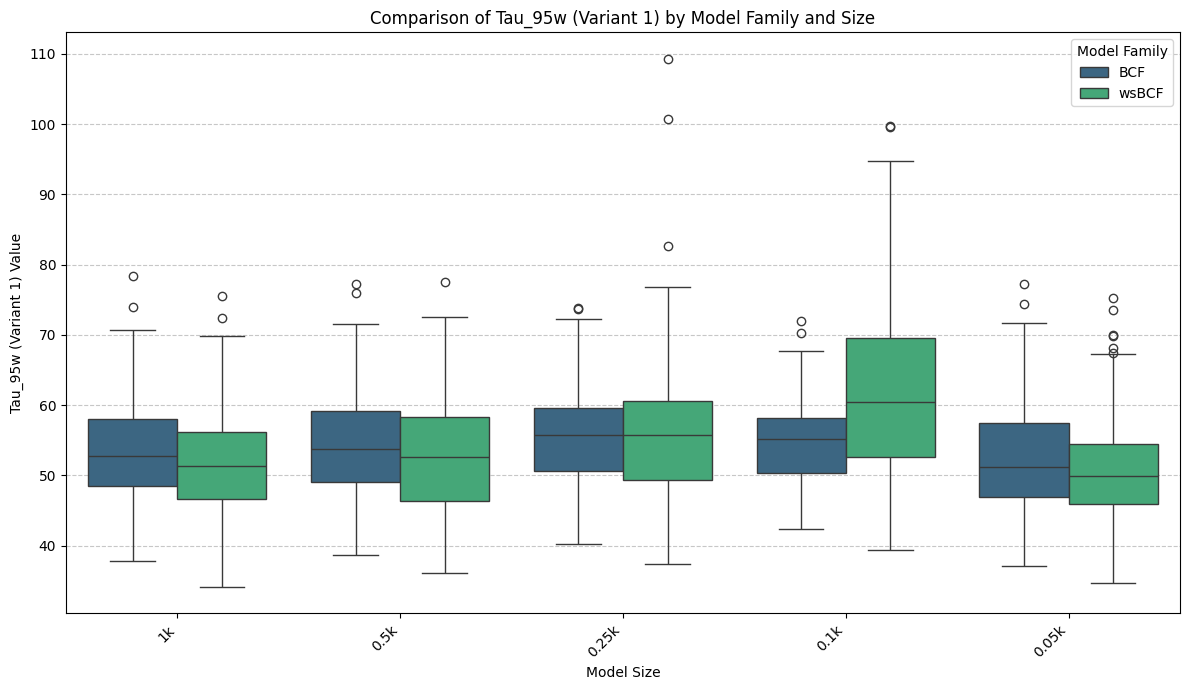

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 49.217 +/- 6.871  48.530 +/- 7.617
 0.5k 49.863 +/- 6.578  49.527 +/- 7.613
0.25k 50.416 +/- 6.366  52.763 +/- 9.147
 0.1k 49.256 +/- 5.856 59.029 +/- 13.553
0.05k 48.909 +/- 6.732  48.032 +/- 6.883




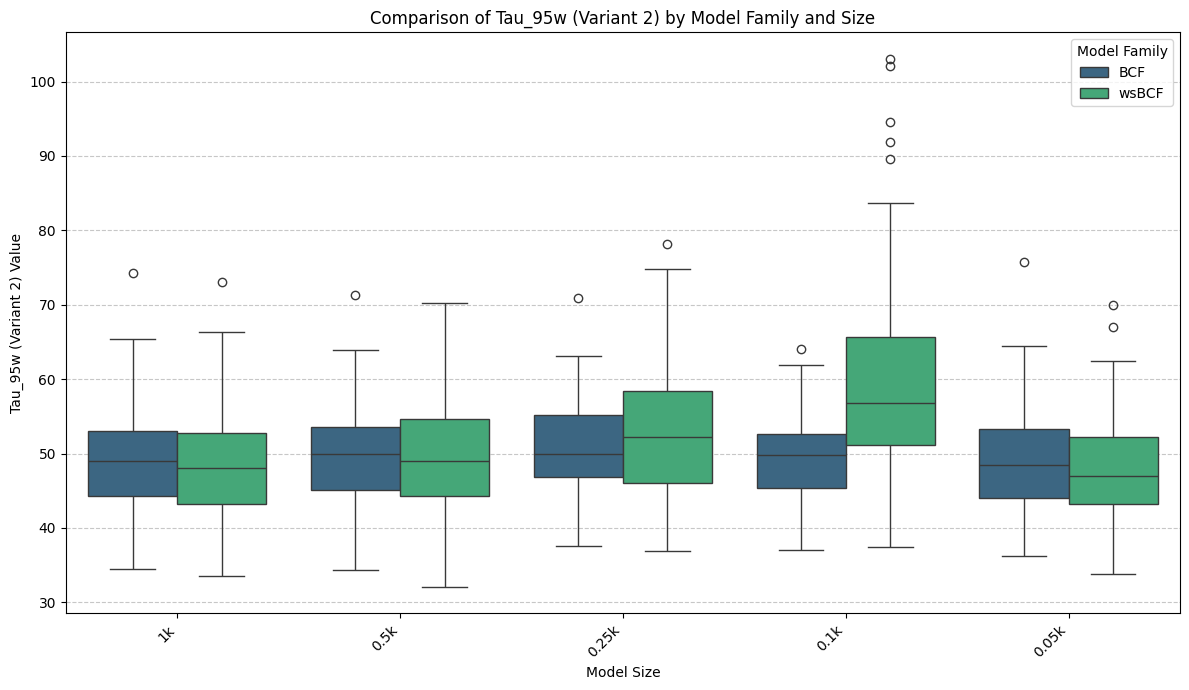

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("multiple_BCF_simulation_results_DGP3.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("multiple_wsBCF_simulation_results_DGP3.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()